In [5]:
import sys
sys.path.append('../src')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#noinspection PyUnresolvedReferences
from model import UNet
#noinspection PyUnresolvedReferences
from dataset import get_dataloader

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cpu


In [14]:
data_dir = '../data/processed/cifar10'
train_loader = get_dataloader(data_dir, batch_size=32, shuffle=True)

print(f"Загружено {len(train_loader.dataset)} изображений")
print(f"Батчей: {len(train_loader)}")

Загружено 1000 изображений
Батчей: 32


In [8]:
model = UNet(in_channels=1, out_channels=3).to(device)

# Функция потерь (MSE)
criterion = nn.MSELoss()

# Оптимизатор
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ Модель готова к обучению")

✅ Модель готова к обучению


In [9]:
def show_prediction(model, gray_batch, color_batch, epoch):
    model.eval()
    with torch.no_grad():
        gray_batch = gray_batch.to(device)
        pred_batch = model(gray_batch)

        # Берем первое изображение из батча
        gray_img = gray_batch[0].cpu().squeeze().numpy()
        pred_img = pred_batch[0].cpu().permute(1, 2, 0).numpy()
        true_img = color_batch[0].cpu().permute(1, 2, 0).numpy()

        # Нормализация
        pred_img = np.clip(pred_img, 0, 1)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(gray_img, cmap='gray')
        axes[0].set_title("Вход (ч/б)")
        axes[0].axis('off')

        axes[1].imshow(pred_img)
        axes[1].set_title(f"Предсказание (эпоха {epoch})")
        axes[1].axis('off')

        axes[2].imshow(true_img)
        axes[2].set_title("Реальное цветное")
        axes[2].axis('off')

        plt.show()

    model.train()

Начинаем обучение...

✅ Эпоха 1 завершена | Средняя потеря: 0.0079
✅ Эпоха 2 завершена | Средняя потеря: 0.0081


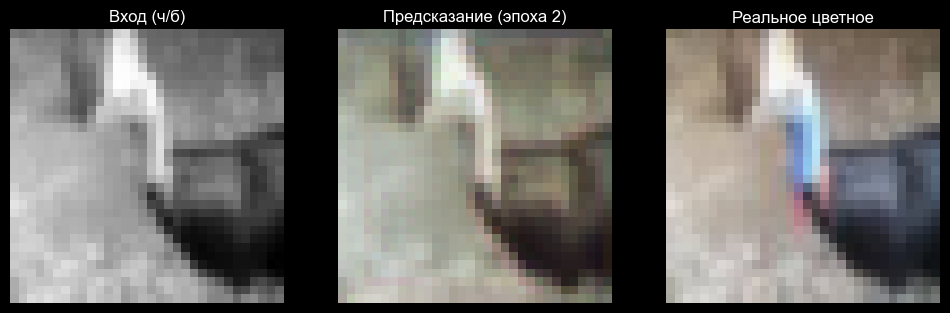

✅ Эпоха 3 завершена | Средняя потеря: 0.0073
✅ Эпоха 4 завершена | Средняя потеря: 0.0077


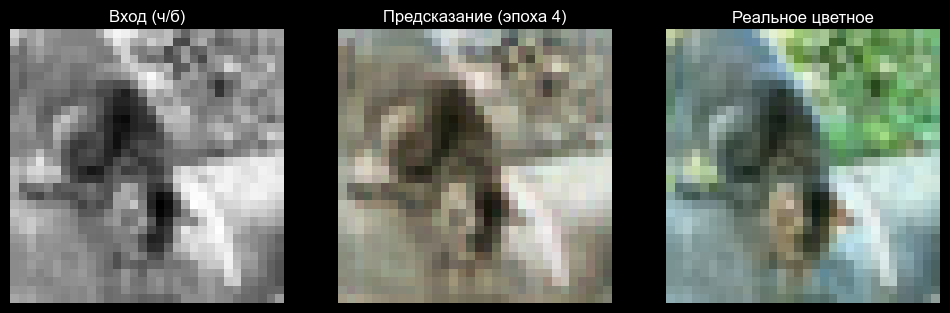

✅ Эпоха 5 завершена | Средняя потеря: 0.0077
✅ Эпоха 6 завершена | Средняя потеря: 0.0075


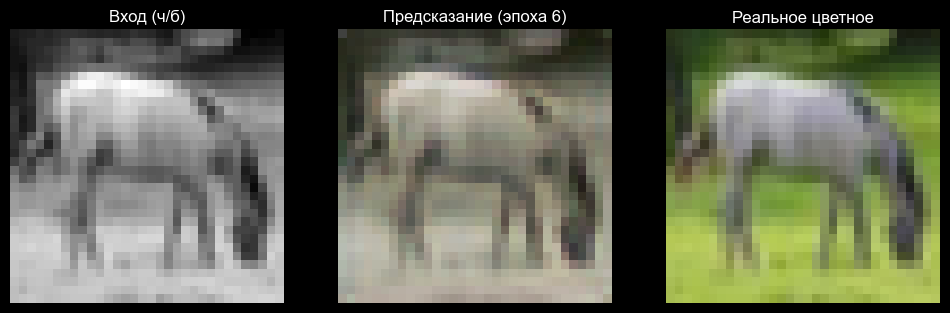

✅ Эпоха 7 завершена | Средняя потеря: 0.0081
✅ Эпоха 8 завершена | Средняя потеря: 0.0072


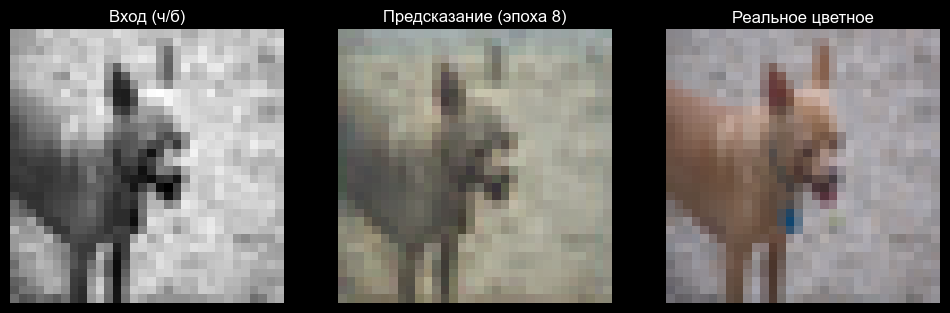

✅ Эпоха 9 завершена | Средняя потеря: 0.0070
✅ Эпоха 10 завершена | Средняя потеря: 0.0070


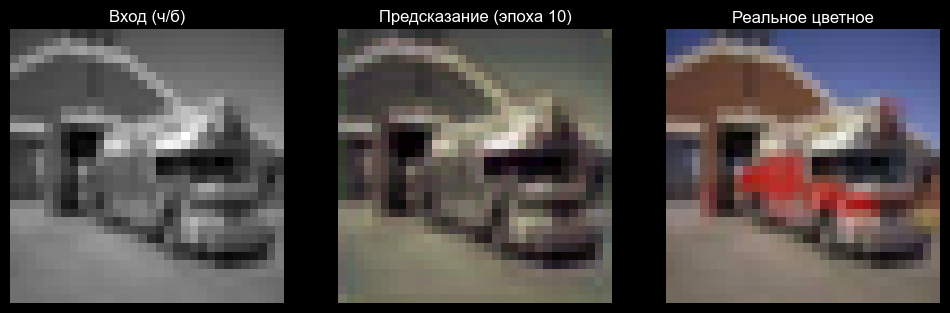

✅ Эпоха 11 завершена | Средняя потеря: 0.0077
✅ Эпоха 12 завершена | Средняя потеря: 0.0070


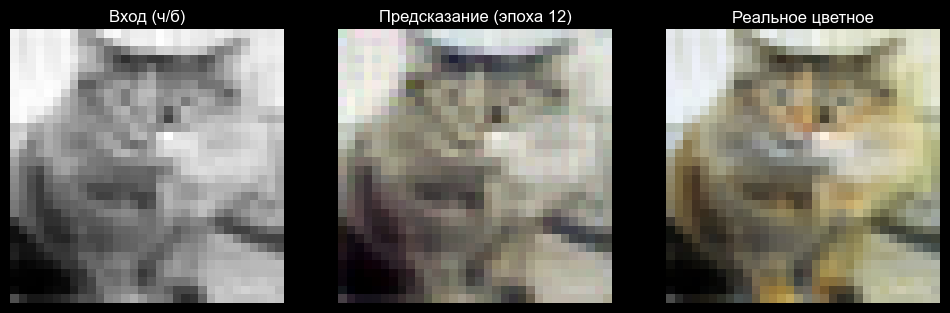

✅ Эпоха 13 завершена | Средняя потеря: 0.0069
✅ Эпоха 14 завершена | Средняя потеря: 0.0070


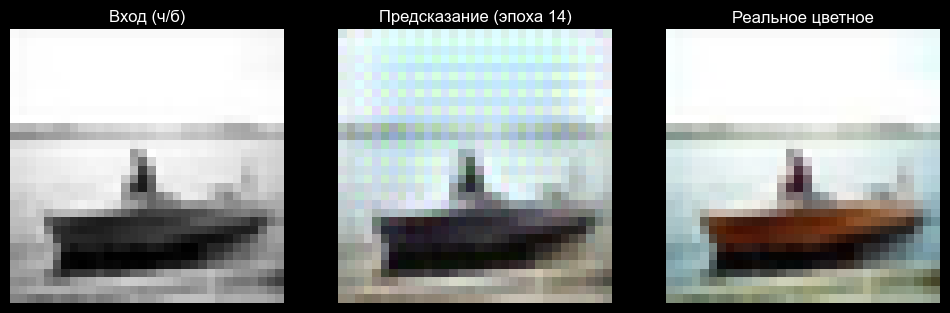

✅ Эпоха 15 завершена | Средняя потеря: 0.0068
✅ Эпоха 16 завершена | Средняя потеря: 0.0073


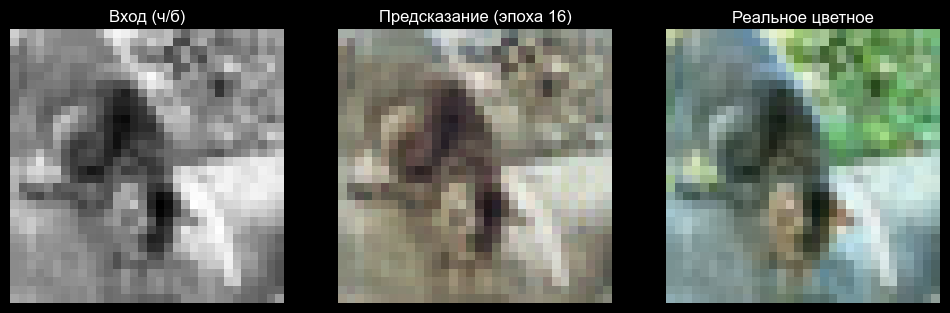

✅ Эпоха 17 завершена | Средняя потеря: 0.0071
✅ Эпоха 18 завершена | Средняя потеря: 0.0069


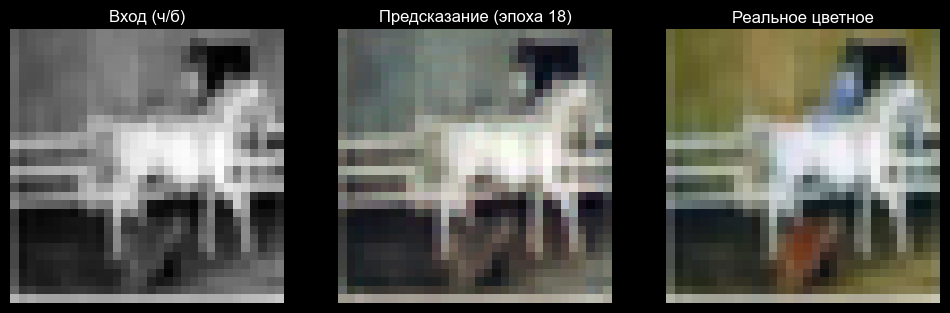

✅ Эпоха 19 завершена | Средняя потеря: 0.0062
✅ Эпоха 20 завершена | Средняя потеря: 0.0067


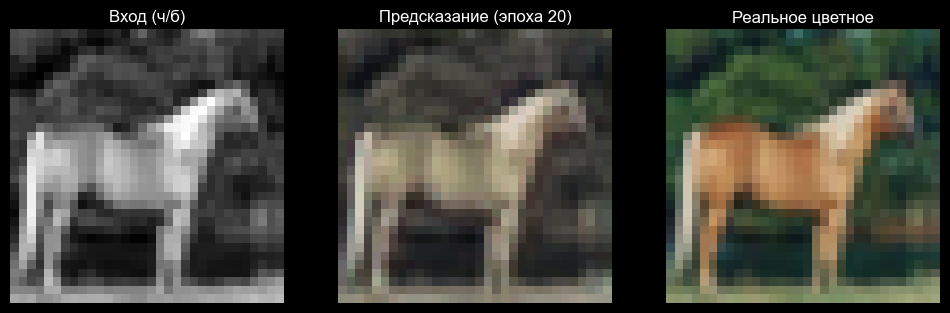

✅ Эпоха 21 завершена | Средняя потеря: 0.0063
✅ Эпоха 22 завершена | Средняя потеря: 0.0069


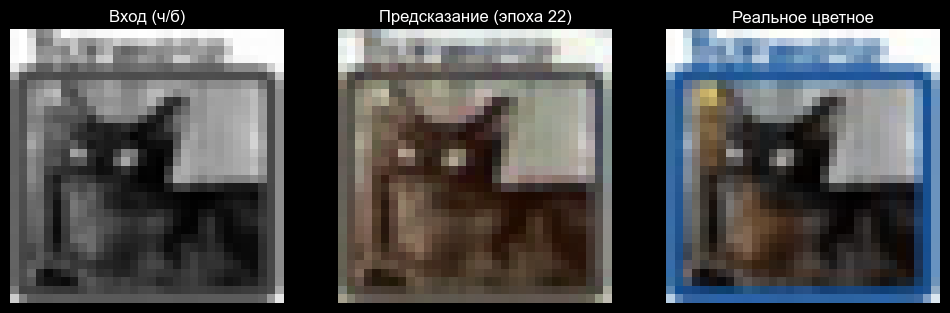

✅ Эпоха 23 завершена | Средняя потеря: 0.0072
✅ Эпоха 24 завершена | Средняя потеря: 0.0067


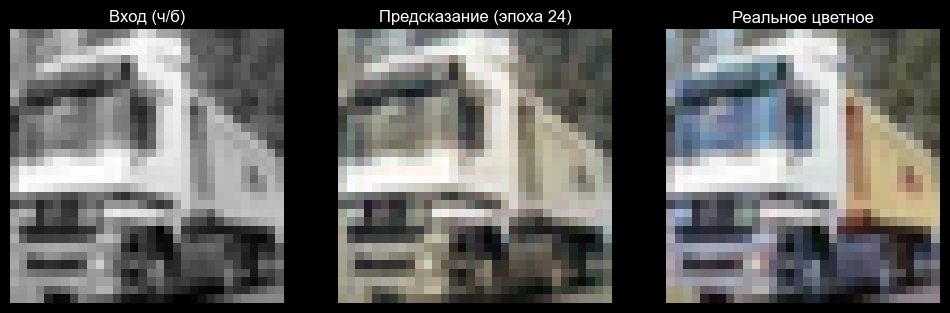

✅ Эпоха 25 завершена | Средняя потеря: 0.0066
✅ Эпоха 26 завершена | Средняя потеря: 0.0074


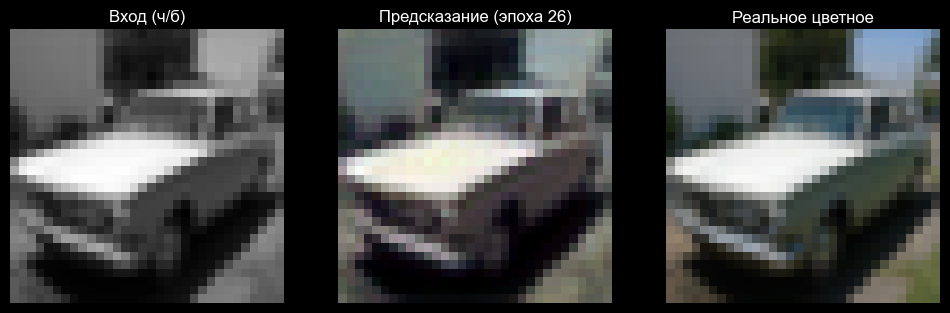

✅ Эпоха 27 завершена | Средняя потеря: 0.0067
✅ Эпоха 28 завершена | Средняя потеря: 0.0071


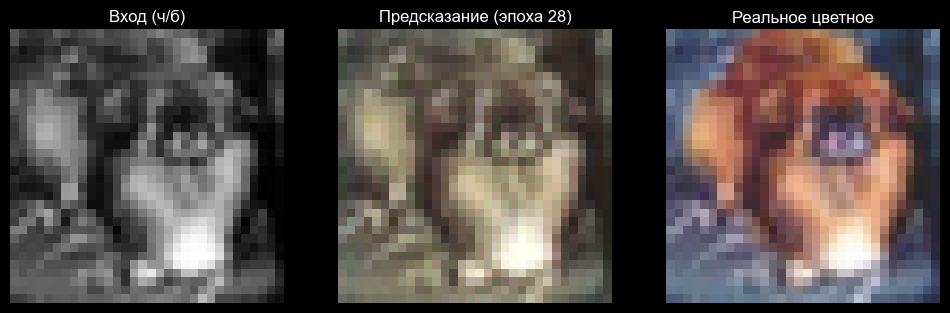

✅ Эпоха 29 завершена | Средняя потеря: 0.0071
✅ Эпоха 30 завершена | Средняя потеря: 0.0062


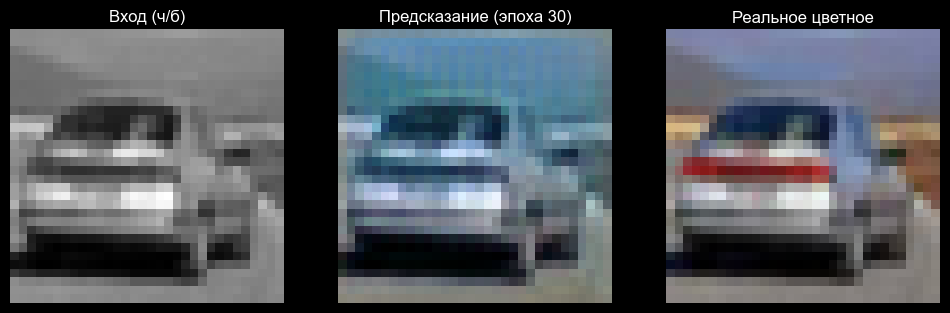

✅ Эпоха 31 завершена | Средняя потеря: 0.0064
✅ Эпоха 32 завершена | Средняя потеря: 0.0060


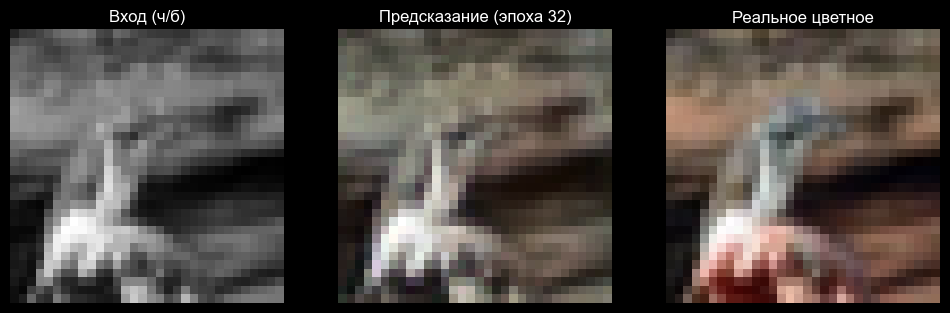

✅ Эпоха 33 завершена | Средняя потеря: 0.0065
✅ Эпоха 34 завершена | Средняя потеря: 0.0062


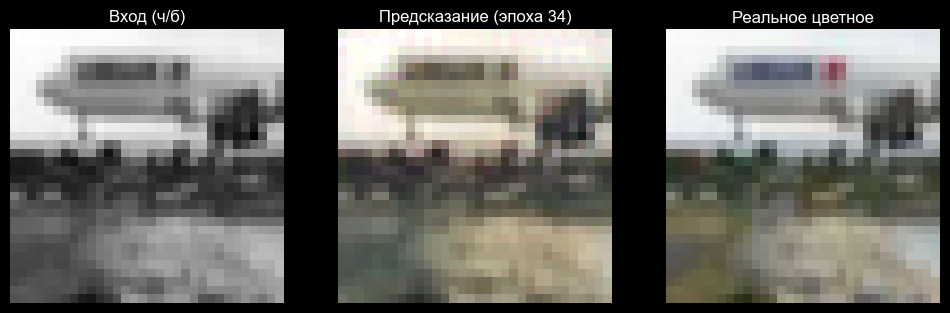

✅ Эпоха 35 завершена | Средняя потеря: 0.0063
✅ Эпоха 36 завершена | Средняя потеря: 0.0065


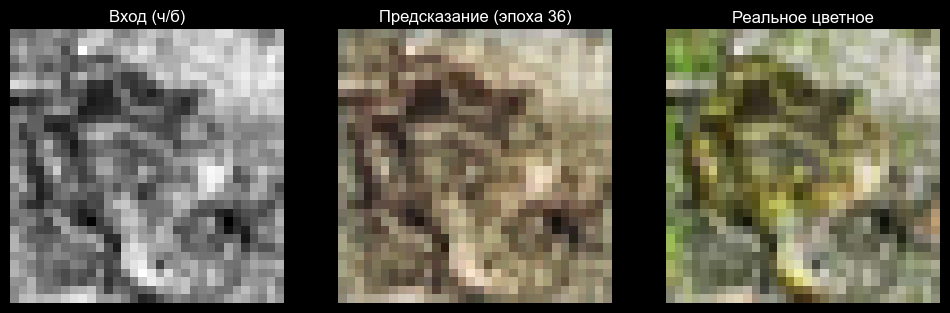

✅ Эпоха 37 завершена | Средняя потеря: 0.0061
✅ Эпоха 38 завершена | Средняя потеря: 0.0059


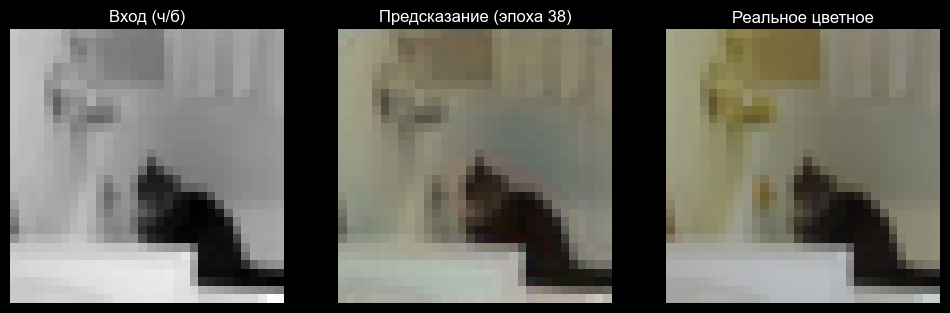

✅ Эпоха 39 завершена | Средняя потеря: 0.0062
✅ Эпоха 40 завершена | Средняя потеря: 0.0061


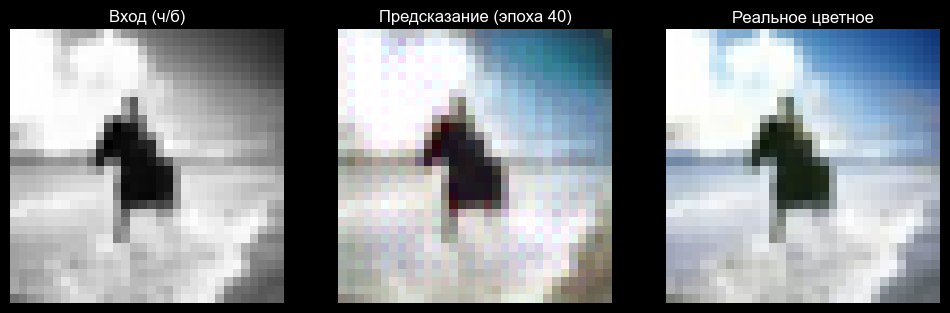

✅ Эпоха 41 завершена | Средняя потеря: 0.0059
✅ Эпоха 42 завершена | Средняя потеря: 0.0058


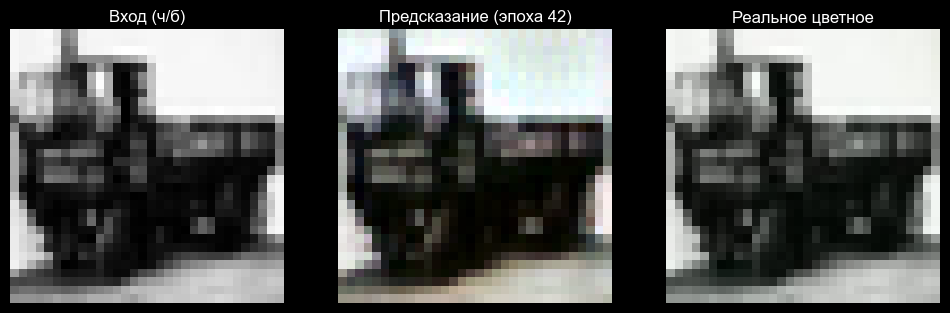

✅ Эпоха 43 завершена | Средняя потеря: 0.0058
✅ Эпоха 44 завершена | Средняя потеря: 0.0062


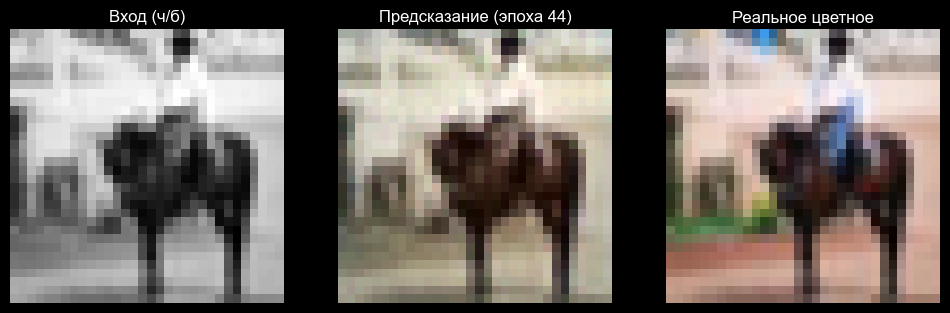

✅ Эпоха 45 завершена | Средняя потеря: 0.0055
✅ Эпоха 46 завершена | Средняя потеря: 0.0054


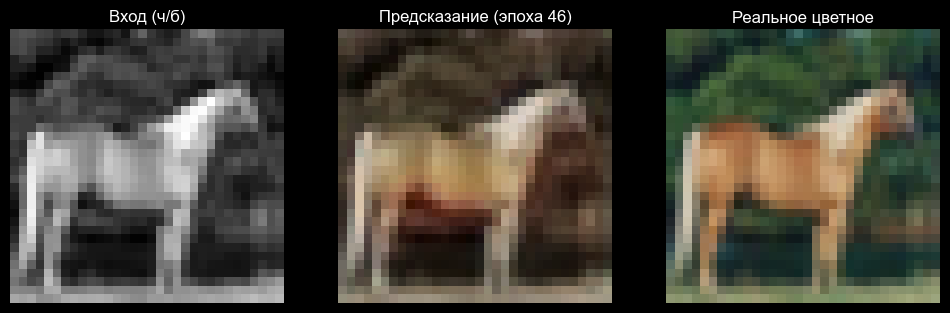

✅ Эпоха 47 завершена | Средняя потеря: 0.0056
✅ Эпоха 48 завершена | Средняя потеря: 0.0061


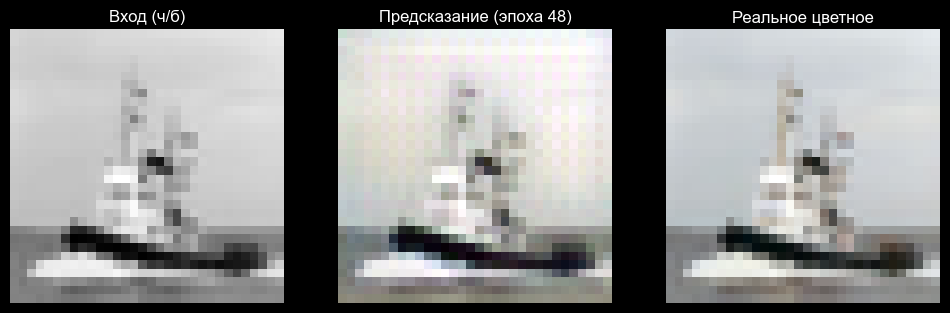

✅ Эпоха 49 завершена | Средняя потеря: 0.0068
✅ Эпоха 50 завершена | Средняя потеря: 0.0053


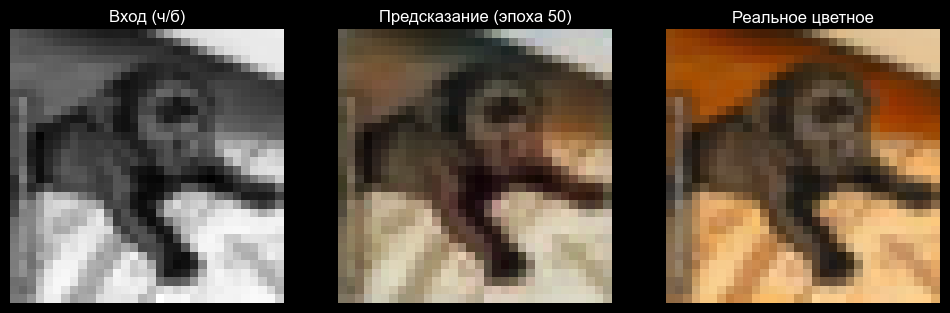

In [11]:
num_epochs = 50
train_losses = []

print("Начинаем обучение...\n")

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for batch_idx, (gray_batch, color_batch) in enumerate(train_loader):
        # Перемещаем данные на GPU
        gray_batch = gray_batch.to(device)
        color_batch = color_batch.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(gray_batch)

        # Вычисляем потерю
        loss = criterion(outputs, color_batch)

        # Обратный проход
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Вывод прогресса
        if (batch_idx + 1) % 50 == 0:
            print(f"Эпоха {epoch+1}/{num_epochs} | Батч {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # Средняя потеря за эпоху
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"✅ Эпоха {epoch+1} завершена | Средняя потеря: {avg_loss:.4f}")

    # Показываем результат каждые 2 эпохи
    if (epoch + 1) % 2 == 0:
        gray_batch, color_batch = next(iter(train_loader))
        show_prediction(model, gray_batch, color_batch, epoch + 1)

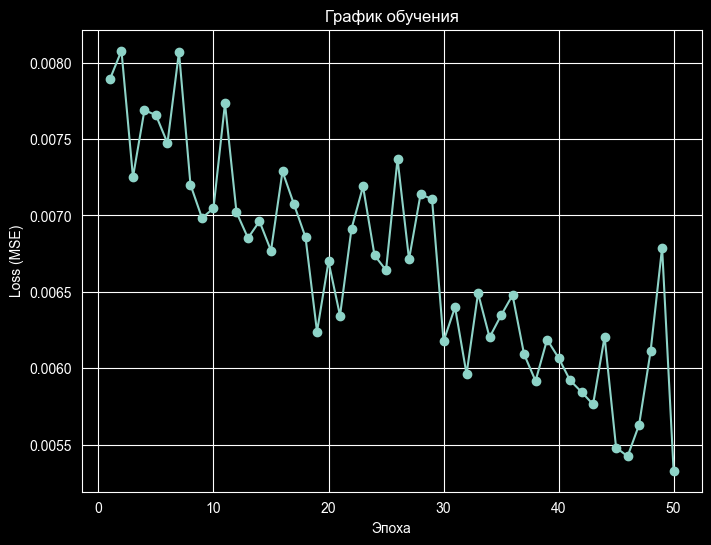

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.title('График обучения')
plt.grid(True)
plt.show()

## Результаты обучения

- Датасет: CIFAR-10 (1000 изображений)
- Размер: 32×32 пикселя
- Модель: U-Net (31 млн параметров)
- Эпох: 50
- Финальная потеря (MSE): ~0.006

**Выводы:**
Модель научилась базовому раскрашиванию — различает небо, землю, объекты. Результаты размытые из-за маленького размера картинок. Для качества нужен датасет 128×128 и больше эпох.